Epoch     0  Loss = 4.282794e+00
Epoch    50  Loss = 3.684148e+00
Epoch   100  Loss = 2.933628e+00
Epoch   150  Loss = 4.407105e+00
Epoch   200  Loss = 2.993253e+00
Epoch   250  Loss = 2.080871e+00
Epoch   300  Loss = 4.010531e+00
Epoch   350  Loss = 3.671528e+00
Epoch   400  Loss = 3.576527e+00
Epoch   450  Loss = 2.414775e+00


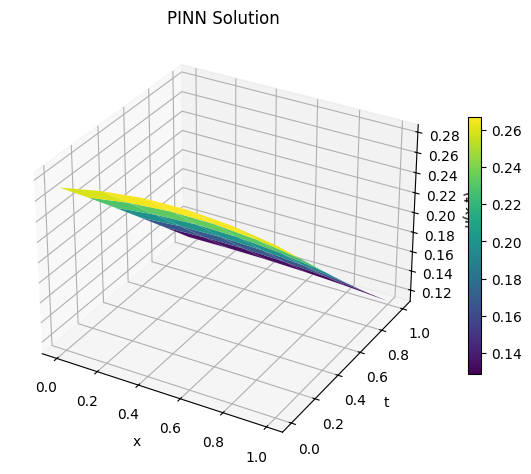

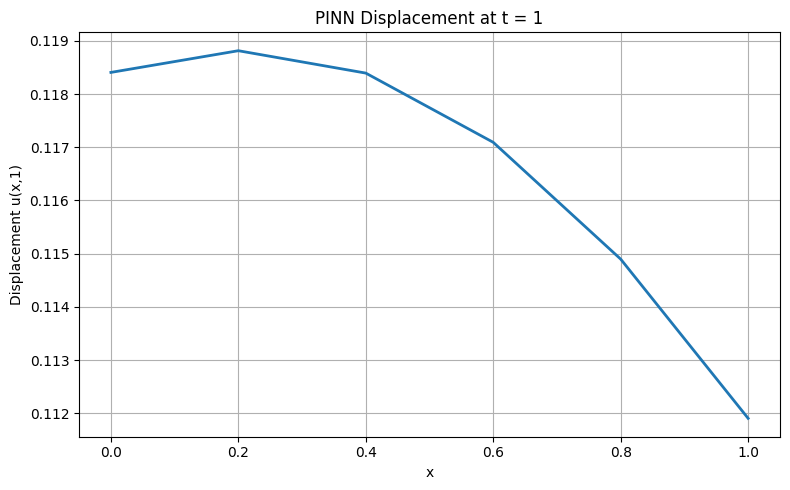

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)
# Wave speed
c = 1.0

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 5),
            nn.Tanh(),

            nn.Linear(5, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = PINN()

# ==========================================================
# Optimizer
# ==========================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # ======================================================
    # Interior points
    # ======================================================

    Nf = 4

    x = torch.rand(Nf, 1, requires_grad=True )

    t = torch.rand(Nf, 1, requires_grad=True )

    u = model(x, t)

    # ======================================================
    # u_x
    # ======================================================
    u_x = torch.autograd.grad(u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    # ======================================================
    # u_xx
    # ======================================================
    u_xx = torch.autograd.grad(u_x,x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]
    # ======================================================
    # u_t
    # ======================================================
    u_t = torch.autograd.grad(u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]
    # ======================================================
    # u_tt
    # ======================================================
    u_tt = torch.autograd.grad(u_t, t,
        grad_outputs=torch.ones_like(u_t),
        create_graph=True
    )[0]
    # ======================================================
    # Wave Equation u_tt - c^2 u_xx = 0
    # ======================================================
    loss_pde = (u_tt - c**2 * u_xx).pow(2).mean()

    # ======================================================
    # Boundary Condition: x = 0, u(0,t) = 0
    # ======================================================

    Nb = 6

    tb = torch.rand(Nb, 1).to(device)

    x_left = torch.zeros_like(tb)

    u_left = model(x_left, tb )

    loss_left = (u_left ** 2 ).mean()

    # ======================================================
    # Boundary Condition: x = 1, u(1,t) = 0
    # ======================================================

    x_right = torch.ones_like(tb)

    u_right = model(x_right, tb )

    loss_right = ( u_right ** 2 ).mean()

    # ======================================================
    # Initial Condition u(x,0) = sin(pi*x)
    # ======================================================

    xi = torch.rand(Nb, 1)

    t_initial = torch.zeros_like(xi)

    u_initial = model(xi, t_initial )

    loss_initial = (u_initial - torch.sin(np.pi * xi)  ).pow(2).mean()

    # ======================================================
    # Initial Velocity Condition u_t(x,0) = 0
    # ======================================================

    xi_velocity = torch.rand(Nb, 1, requires_grad=True )

    t_velocity = torch.zeros_like(xi_velocity, requires_grad=True )

    u_velocity = model(xi_velocity, t_velocity )

    u_t_initial = torch.autograd.grad(u_velocity, t_velocity,
        grad_outputs=torch.ones_like(u_velocity),
        create_graph=True
    )[0]

    loss_velocity = (u_t_initial ** 2).mean()

    # ======================================================
    # Total PINN Loss
    # ======================================================

    loss = (loss_pde + 10 * loss_left + 10 * loss_right + 10 * loss_initial  + 10 * loss_velocity )

    return loss


# ==========================================================
# Training
# ==========================================================

epochs = 500

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:

        print(f"Epoch {epoch:5d}  " f"Loss = {loss.item():.6e}")


# ==========================================================
# Prediction
# ==========================================================

n_x = 6
n_t = 6

x_test = torch.linspace(0, 1, n_x)

t_test = torch.linspace(0, 1, n_t)

X, T = torch.meshgrid(x_test, t_test, indexing="ij")

x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)

# ==========================================================
# PINN Prediction
# ==========================================================

with torch.no_grad():

    u_pinn = model(x_flat, t_flat )

u_pinn = u_pinn.reshape(n_x, n_t).numpy()


# ==========================================================
# Plot PINN Solution
# ==========================================================

fig = plt.figure()

ax = fig.add_subplot(1, 1, 1, projection="3d")

surf = ax.plot_surface(X.cpu().numpy(), T.cpu().numpy(), u_pinn, cmap="viridis")

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u(x,t)")

ax.set_title("PINN Solution")

fig.colorbar(surf,  ax=ax, shrink=0.6)

plt.tight_layout()

plt.show()
# ==========================================================
# Prediction at t = 1
# ==========================================================
n_x = 6

x_test = torch.linspace(0, 1, n_x)

t_test = torch.ones_like(x_test)   # t = 1
# ==========================================================
#If we need displacement only at time t=1, then
# PINN Prediction
# ==========================================================
with torch.no_grad():

    u_pinn = model(x_test.reshape(-1, 1), t_test.reshape(-1, 1) )

u_pinn = u_pinn.numpy().flatten()

# ==========================================================
# Plot Displacement at t = 1
# ==========================================================
plt.figure(figsize=(8, 5))

plt.plot(x_test.numpy(),u_pinn, linewidth=2)

plt.xlabel("x")
plt.ylabel("Displacement u(x,1)")
plt.title("PINN Displacement at t = 1")

plt.grid(True)

plt.tight_layout()

plt.show()

Training with Adam...
Epoch     0  Loss = 4.947399e+00
Epoch  1000  Loss = 1.144171e-02
Epoch  2000  Loss = 3.840757e-03
Epoch  3000  Loss = 5.338208e-03
Epoch  4000  Loss = 1.022265e-03


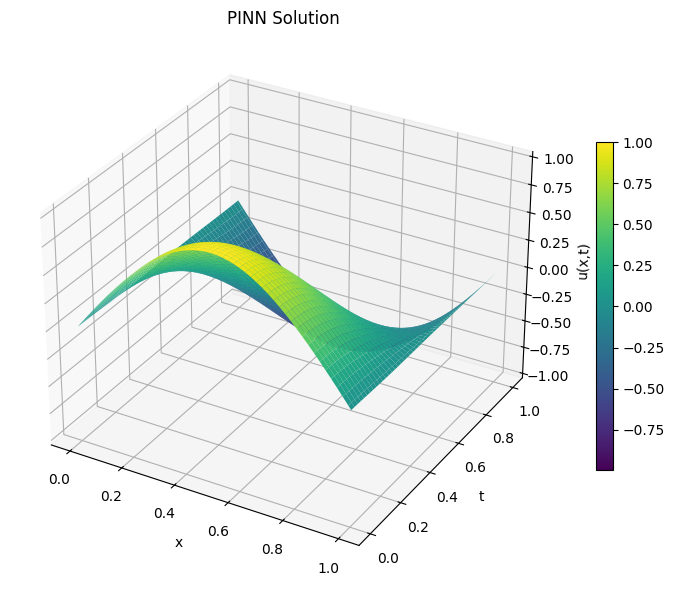

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device("cpu")

# Wave speed
c = 1.0

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


model = PINN().to(device)

# ==========================================================
# Optimizer
# ==========================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # ======================================================
    # Interior points
    # ======================================================

    Nf = 1000

    x = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    t = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    u = model(x, t)

    # ======================================================
    # u_x
    # ======================================================

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ======================================================
    # u_xx
    # ======================================================

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    # ======================================================
    # u_t
    # ======================================================

    u_t = torch.autograd.grad(
        u,
        t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ======================================================
    # u_tt
    # ======================================================

    u_tt = torch.autograd.grad(
        u_t,
        t,
        grad_outputs=torch.ones_like(u_t),
        create_graph=True
    )[0]

    # ======================================================
    # Wave Equation
    #
    # u_tt - c^2 u_xx = 0
    # ======================================================

    loss_pde = (
        u_tt - c**2 * u_xx
    ).pow(2).mean()

    # ======================================================
    # Boundary Condition: x = 0
    # u(0,t) = 0
    # ======================================================

    Nb = 500

    tb = torch.rand(Nb, 1).to(device)

    x_left = torch.zeros_like(tb)

    u_left = model(
        x_left,
        tb
    )

    loss_left = (
        u_left ** 2
    ).mean()

    # ======================================================
    # Boundary Condition: x = 1
    # u(1,t) = 0
    # ======================================================

    x_right = torch.ones_like(tb)

    u_right = model(
        x_right,
        tb
    )

    loss_right = (
        u_right ** 2
    ).mean()

    # ======================================================
    # Initial Condition
    #
    # u(x,0) = sin(pi*x)
    # ======================================================

    xi = torch.rand(Nb, 1).to(device)

    t_initial = torch.zeros_like(xi)

    u_initial = model(
        xi,
        t_initial
    )

    target_initial = torch.sin(
        np.pi * xi
    )

    loss_initial = (
        u_initial - target_initial
    ).pow(2).mean()

    # ======================================================
    # Initial Velocity Condition
    #
    # u_t(x,0) = 0
    # ======================================================

    xi_velocity = torch.rand(
        Nb, 1,
        requires_grad=True
    ).to(device)

    t_velocity = torch.zeros_like(
        xi_velocity,
        requires_grad=True
    )

    u_velocity = model(
        xi_velocity,
        t_velocity
    )

    u_t_initial = torch.autograd.grad(
        u_velocity,
        t_velocity,
        grad_outputs=torch.ones_like(
            u_velocity
        ),
        create_graph=True
    )[0]

    loss_velocity = (
        u_t_initial ** 2
    ).mean()

    # ======================================================
    # Total PINN Loss
    # ======================================================

    loss = (
        loss_pde
        + 10 * loss_left
        + 10 * loss_right
        + 10 * loss_initial
        + 10 * loss_velocity
    )

    return loss


# ==========================================================
# Adam Training
# ==========================================================

epochs = 5000

print("Training with Adam...")

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch:5d}  "
            f"Loss = {loss.item():.6e}"
        )


# ==========================================================
# Prediction
# ==========================================================

n_x = 100
n_t = 100

x_test = torch.linspace(
    0, 1, n_x
).to(device)

t_test = torch.linspace(
    0, 1, n_t
).to(device)

X, T = torch.meshgrid(
    x_test,
    t_test,
    indexing="ij"
)

x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)

# ==========================================================
# PINN Prediction
# ==========================================================

with torch.no_grad():

    u_pinn = model(
        x_flat,
        t_flat
    )

u_pinn = u_pinn.reshape(
    n_x,
    n_t
).cpu().numpy()


# ==========================================================
# Plot PINN Solution
# ==========================================================

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(
    1, 1, 1,
    projection="3d"
)

surf = ax.plot_surface(
    X.cpu().numpy(),
    T.cpu().numpy(),
    u_pinn,
    cmap="viridis"
)

ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u(x,t)")

ax.set_title(
    "PINN Solution"
)

fig.colorbar(
    surf,
    ax=ax,
    shrink=0.6
)

plt.tight_layout()

plt.show()

Training with Adam...
Epoch     0  Loss = 4.947399e+00
Epoch  1000  Loss = 1.144171e-02
Epoch  2000  Loss = 3.840757e-03
Epoch  3000  Loss = 5.338208e-03
Epoch  4000  Loss = 1.022265e-03

Starting L-BFGS optimization...
L-BFGS Finished!

Comparison:
Maximum absolute error = 8.193851e-03
Mean absolute error    = 2.537566e-03
RMSE                   = 3.149919e-03


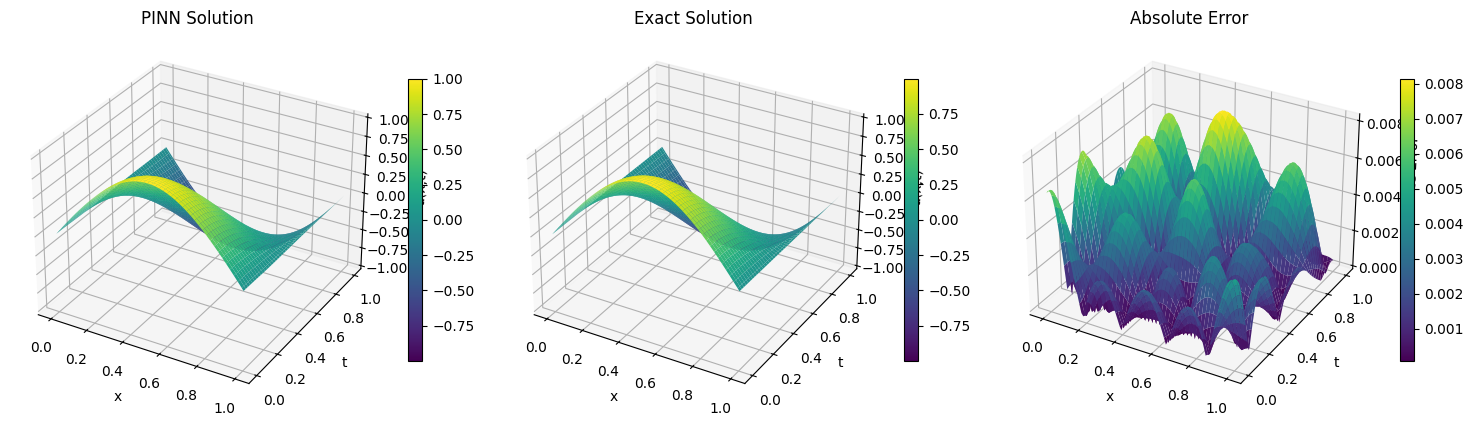

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================================
# Parameters
# ==========================================================

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device("cpu")

# Wave speed
c = 1.0

# ==========================================================
# PINN Network
# ==========================================================

class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


model = PINN().to(device)

# ==========================================================
# Optimizers
# ==========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5000,
    gamma=0.5
)

# ==========================================================
# PINN Loss
# ==========================================================

def pinn_loss():

    # ======================================================
    # Interior points
    # ======================================================

    Nf = 1000

    x = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    t = torch.rand(
        Nf, 1,
        requires_grad=True
    ).to(device)

    u = model(x, t)

    # ======================================================
    # u_x
    # ======================================================

    u_x = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ======================================================
    # u_xx
    # ======================================================

    u_xx = torch.autograd.grad(
        u_x,
        x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    # ======================================================
    # u_t
    # ======================================================

    u_t = torch.autograd.grad(
        u,
        t,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # ======================================================
    # u_tt
    # ======================================================

    u_tt = torch.autograd.grad(
        u_t,
        t,
        grad_outputs=torch.ones_like(u_t),
        create_graph=True
    )[0]

    # ======================================================
    # Wave Equation
    #
    # u_tt = c^2 u_xx
    #
    # Residual:
    #
    # u_tt - c^2 u_xx = 0
    # ======================================================

    residual = u_tt - c**2 * u_xx

    loss_pde = residual.pow(2).mean()

    # ======================================================
    # Boundary Condition: x = 0
    #
    # u(0,t) = 0
    # ======================================================

    Nb = 500

    tb = torch.rand(
        Nb, 1
    ).to(device)

    x_left = torch.zeros_like(tb)

    u_left = model(
        x_left,
        tb
    )

    loss_left = (
        u_left ** 2
    ).mean()

    # ======================================================
    # Boundary Condition: x = 1
    #
    # u(1,t) = 0
    # ======================================================

    x_right = torch.ones_like(tb)

    u_right = model(
        x_right,
        tb
    )

    loss_right = (
        u_right ** 2
    ).mean()

    # ======================================================
    # Initial Condition
    #
    # u(x,0) = sin(pi*x)
    # ======================================================

    xi = torch.rand(
        Nb, 1
    ).to(device)

    t_initial = torch.zeros_like(xi)

    u_initial = model(
        xi,
        t_initial
    )

    target_initial = torch.sin(
        np.pi * xi
    )

    loss_initial = (
        u_initial - target_initial
    ).pow(2).mean()

    # ======================================================
    # Initial Velocity Condition
    #
    # u_t(x,0) = 0
    # ======================================================

    xi_velocity = torch.rand(
        Nb, 1,
        requires_grad=True
    ).to(device)

    t_velocity = torch.zeros_like(
        xi_velocity,
        requires_grad=True
    )

    u_velocity = model(
        xi_velocity,
        t_velocity
    )

    u_t_initial = torch.autograd.grad(
        u_velocity,
        t_velocity,
        grad_outputs=torch.ones_like(
            u_velocity
        ),
        create_graph=True
    )[0]

    loss_velocity = (
        u_t_initial ** 2
    ).mean()

    # ======================================================
    # Total PINN Loss
    # ======================================================

    loss = (
        loss_pde
        + 10 * loss_left
        + 10 * loss_right
        + 10 * loss_initial
        + 10 * loss_velocity
    )

    return loss


# ==========================================================
# Adam Training
# ==========================================================

epochs = 5000

print("Training with Adam...")

for epoch in range(epochs):

    loss = pinn_loss()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    scheduler.step()

    if epoch % 1000 == 0:

        print(
            f"Epoch {epoch:5d}  "
            f"Loss = {loss.item():.6e}"
        )


# ==========================================================
# L-BFGS Fine Tuning
# ==========================================================

print("\nStarting L-BFGS optimization...")

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=500,
    tolerance_grad=1e-9,
    tolerance_change=1e-9,
    history_size=100,
    line_search_fn="strong_wolfe"
)


def closure():

    optimizer_lbfgs.zero_grad()

    loss = pinn_loss()

    loss.backward()

    return loss


optimizer_lbfgs.step(closure)

print("L-BFGS Finished!")


# ==========================================================
# Prediction
# ==========================================================

n_x = 100
n_t = 100

x_test = torch.linspace(
    0, 1, n_x
).to(device)

t_test = torch.linspace(
    0, 1, n_t
).to(device)

X, T = torch.meshgrid(
    x_test,
    t_test,
    indexing="ij"
)

x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)


# ==========================================================
# PINN Prediction
# ==========================================================

with torch.no_grad():

    u_pinn = model(
        x_flat,
        t_flat
    )

u_pinn = u_pinn.reshape(
    n_x,
    n_t
).cpu().numpy()


# ==========================================================
# Exact Solution
# ==========================================================

def exact_solution(x, t):

    return (
        np.sin(np.pi * x)
        * np.cos(np.pi * t)
    )


u_exact = exact_solution(
    X.cpu().numpy(),
    T.cpu().numpy()
)


# ==========================================================
# Absolute Error
# ==========================================================

error = np.abs(
    u_pinn - u_exact
)

print("\nComparison:")

print(
    f"Maximum absolute error = "
    f"{np.max(error):.6e}"
)

print(
    f"Mean absolute error    = "
    f"{np.mean(error):.6e}"
)

print(
    f"RMSE                   = "
    f"{np.sqrt(np.mean(error**2)):.6e}"
)


# ==========================================================
# Plot: PINN vs Exact
# ==========================================================

fig = plt.figure(figsize=(15, 5))

# ----------------------------------------------------------
# PINN Solution
# ----------------------------------------------------------

ax1 = fig.add_subplot(
    1, 3, 1,
    projection="3d"
)

surf1 = ax1.plot_surface(
    X.cpu().numpy(),
    T.cpu().numpy(),
    u_pinn,
    cmap="viridis"
)

ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_zlabel("u(x,t)")

ax1.set_title(
    "PINN Solution"
)

fig.colorbar(
    surf1,
    ax=ax1,
    shrink=0.6
)


# ----------------------------------------------------------
# Exact Solution
# ----------------------------------------------------------

ax2 = fig.add_subplot(
    1, 3, 2,
    projection="3d"
)

surf2 = ax2.plot_surface(
    X.cpu().numpy(),
    T.cpu().numpy(),
    u_exact,
    cmap="viridis"
)

ax2.set_xlabel("x")
ax2.set_ylabel("t")
ax2.set_zlabel("u(x,t)")

ax2.set_title(
    "Exact Solution"
)

fig.colorbar(
    surf2,
    ax=ax2,
    shrink=0.6
)


# ----------------------------------------------------------
# Absolute Error
# ----------------------------------------------------------

ax3 = fig.add_subplot(
    1, 3, 3,
    projection="3d"
)

surf3 = ax3.plot_surface(
    X.cpu().numpy(),
    T.cpu().numpy(),
    error,
    cmap="viridis"
)

ax3.set_xlabel("x")
ax3.set_ylabel("t")
ax3.set_zlabel("Absolute Error")

ax3.set_title(
    "Absolute Error"
)

fig.colorbar(
    surf3,
    ax=ax3,
    shrink=0.6
)

plt.tight_layout()

plt.show()